<!-- Could you make one additional figure: 1 non-converter, 1 converter, and all survival curves for n=200 and n=30000 and frozen/fine-tuned (so 2x2x2)? -->

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import pandas as pd
import numpy as np
import pickle
import os

In [3]:
log_dir = '/home/berens/bep973/ifeoma_home/leverage-data/log_dir'
CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
CHKPT_DIR= chkpt_dir ='/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/checkpoints/npj_june_areds'
root_dir = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds/datasets'
csv_dir = os.path.dirname(root_dir)
print(csv_dir)
split_id = 11042026

/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds


## Prelim

In [3]:
surv_log_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
surv_log_df.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [5]:
ex1 = surv_log_df.iloc[0]
ex1

Name                   testrun_False_FE_False_100_linear_2026-06-15_1...
State                                                           finished
Notes                                                                  -
User                                                                 NaN
Tags                                                                 NaN
                                             ...                        
val/ibs                                                          0.08436
val/ibs_best                                                    0.084258
val/mean_auroc                                                  0.772707
val/mean_auroc_best                                             0.762622
summary                                                 simclr_inet_nako
Name: 0, Length: 71, dtype: object

In [6]:
log_file_path = os.path.join(chkpt_dir, ex1['Name'])
os.listdir(log_file_path)

['config.yaml', 'val_survival_curves.csv', 'test_survival_curves.csv']

In [7]:
surv_curves = pd.read_csv(os.path.join(log_file_path, 'test_survival_curves.csv'))
surv_curves.head()

,survival_curve,event,duration,image_name
0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg
1,[0.97084301 0.95361841 0.94389343 0.93204765 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg
2,[0.97136529 0.95444193 0.94488457 0.93324055 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg
3,[0.97631802 0.96226443 0.95430851 0.94459649 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg
4,[0.97210068 0.9556019 0.94628096 0.93492166 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg


In [8]:
surv_curves['ID'] = surv_curves['image_name'].apply(lambda x : x.split('_')[0])
surv_curves['visit_number'] = surv_curves['image_name'].apply(lambda x : x.split('_')[1])
surv_curves['image_side'] = surv_curves['image_name'].apply(lambda x : x.split('_')[-2])
surv_curves.head()

,survival_curve,event,duration,image_name,ID,visit_number,image_side
0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg,55353,04,LE
1,[0.97084301 0.95361841 0.94389343 0.93204765 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg,55353,06,LE
2,[0.97136529 0.95444193 0.94488457 0.93324055 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg,55353,08,LE
3,[0.97631802 0.96226443 0.95430851 0.94459649 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg,55353,10,LE
4,[0.97210068 0.9556019 0.94628096 0.93492166 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg,55353,12,LE


In [9]:
surv_curves_plot = surv_curves[surv_curves['image_side']=='LE'].reset_index()
surv_curves_plot.head(1)

,index,survival_curve,event,duration,image_name,ID,visit_number,image_side
0,0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg,55353,04,LE


In [10]:
to_plot = surv_curves_plot.loc[10]
to_plot

index                                                            20
survival_curve    [0.97345673 0.95774227 0.94885854 0.93802622 0...
event                                                    tensor(1.)
duration                                                  tensor(0)
image_name                                    57209_04_F2_LE_LS.jpg
ID                                                            57209
visit_number                                                     04
image_side                                                       LE
Name: 10, dtype: object

In [11]:
s = surv_curves_plot.loc[10, 'survival_curve']
values = [float(x) for x in s.strip('[]').split()]
values

[0.97345673, 0.95774227, 0.94885854, 0.93802622, 0.92560254]

In [23]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()


/tmp/ipykernel_1609510/1714322262.py:1: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1001,1001_left,1001_left_RS_04,4,left,F2,RS,51685_04_F2_LE_RS.jpg,51685/51685_04_F2_LE_RS.jpg,3.0,...,4.0,N,N,6.0,N,74.4,1001_left,1001_left_4,16,0
1,1001,1001_left,1001_left_LS_06,6,left,F2,LS,51685_06_F2_LE_LS.jpg,51685/51685_06_F2_LE_LS.jpg,3.0,...,4.0,N,N,6.0,N,75.4,1001_left,1001_left_6,14,0
2,1001,1001_left,1001_left_LS_08,8,left,F2,LS,51685_08_F2_LE_LS.jpg,51685/51685_08_F2_LE_LS.jpg,2.0,...,4.0,N,N,6.0,N,76.4,1001_left,1001_left_8,12,0
3,1001,1001_left,1001_left_RS_10,10,left,F2,RS,51685_10_F2_LE_RS.jpg,51685/51685_10_F2_LE_RS.jpg,4.0,...,4.0,N,N,6.0,N,77.5,1001_left,1001_left_10,10,0
4,1001,1001_left,1001_left_LS_14,14,left,F2,LS,51685_14_F2_LE_LS.jpg,51685/51685_14_F2_LE_LS.jpg,6.0,...,4.0,N,N,6.0,N,80.1,1001_left,1001_left_14,6,0


In [24]:
patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,G617,G617_right,G617_right_RS_08,8,right,F2,RS,53179_08_F2_RE_RS.jpg,53179/53179_08_F2_RE_RS.jpg,5.0,...,4.0,N,N,6.0,Y,72.8,G617_right,G617_right_8,8,0
11138,G617,G617_right,G617_right_LS_10,10,right,F2,LS,53179_10_F2_RE_LS.jpg,53179/53179_10_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,73.8,G617_right,G617_right_10,6,0
11139,G617,G617_right,G617_right_LS_12,12,right,F2,LS,53179_12_F2_RE_LS.jpg,53179/53179_12_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,75.0,G617_right,G617_right_12,4,0
11140,G617,G617_right,G617_right_LS_14,14,right,F2,LS,53179_14_F2_RE_LS.jpg,53179/53179_14_F2_RE_LS.jpg,8.0,...,4.0,N,N,6.0,Y,76.0,G617_right,G617_right_14,2,0


In [25]:
test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
test_grp['n_img'].value_counts()

n_img
10    273
1     246
9     243
8     171
5     144
4     139
6     135
11    108
7     108
2      94
3      83
12     12
Name: count, dtype: int64

In [27]:
test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
test_grp['has_event'].value_counts()

has_event
False    1368
True      388
Name: count, dtype: int64

In [28]:
sample0_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == True)].reset_index(drop = False)
num0 = 13#random.randint(0,(len(sample_)-1))\n",
print(num0)

13


In [29]:
all_images_to_plot0 =  sample0_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot0

image_path             [4074/4074_00_RE_F2_LS.jpg, 4074/4074_04_RE_F2...
diagnosis_amd_grade                           [6.0, 7.0, 7.0, 7.0, 11.0]
patient_id                                [4074, 4074, 4074, 4074, 4074]
visit_number                                            [0, 4, 6, 8, 10]
Name: 13, dtype: object

## Plot

In [4]:
METADATA_CSV = os.path.join(root_dir,'surv_jul_data0_11_04_26.csv')
areds_df = pd.read_csv(METADATA_CSV)
df_ssl = areds_df.sort_values(['eye_id', 'visit_number']).groupby(['eye_id']).agg(list).reset_index()


/tmp/ipykernel_1872072/4165426703.py:2: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  areds_df = pd.read_csv(METADATA_CSV)


In [5]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [6]:
dfl = or_df[(or_df['freeze_encoder'] == 1) & (or_df['survival_head'] == 'mlp') & (or_df['train_size'] == 32500)]
dfl_ssl = dfl.groupby('weights_path').agg(list)
dfl_ssl.head()

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
weights_path,,,,,,,,,,,,,,,,,,,,,
dino_meta,[testrun_False_FE_True_None_mlp_2026-06-09_01-...,"[finished, finished, finished, finished, finis...","[-, -, -, -, -]","[nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan]","[2026-06-08T23:43:18.000Z, 2026-06-08T09:34:30...","[34187, 36321, 38016, 33666, 30394]","[nan, nan, nan, nan, nan]","[dino_pretrained_224, dino_pretrained_224, din...","[64, 64, 64, 64, 64]",...,"[0.0479710392384596, 0.048294899838315, 0.0485...","[0.0583268988918555, 0.0584826377617599, 0.057...","[0.0673045326466961, 0.0673375620980565, 0.066...","[[0.03668610558640598,0.04797103923845964,0.05...","[0.91094125585736, 0.909635464666148, 0.914283...","[0.0575427662925674, 0.0575625490568212, 0.057...","[0.056833358506384, 0.0567009634129581, 0.0577...","[0.9190991805704544, 0.9178865587370292, 0.924...","[0.9238947140047448, 0.9225107255540026, 0.918...","[dino_meta, dino_meta, dino_meta, dino_meta, d..."
dino_nako,[testrun_False_FE_True_None_mlp_2026-06-08_12-...,"[finished, finished, finished, finished, finis...","[-, -, -, -, -]","[nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan]","[2026-06-08T10:40:18.000Z, 2026-06-07T19:12:36...","[30873, 32987, 23930, 33299, 32332]","[nan, nan, nan, nan, nan]","[dino_nako, dino_nako, dino_nako, dino_nako, d...","[64, 64, 64, 64, 64]",...,"[0.04879574534789, 0.0486429709546973, 0.04839...","[0.05863142459175, 0.0583562445564625, 0.05844...","[0.0680511797460499, 0.0681787059547949, 0.067...","[[0.03772650261135779,0.04879574534789001,0.05...","[0.9074120027081086, 0.9102666922576806, 0.909...","[0.0580225051745787, 0.0577703078161617, 0.057...","[0.0569687150735922, 0.0569438530007918, 0.057...","[0.9168904210811244, 0.9185416677611652, 0.920...","[0.9181923353530456, 0.9192265454129034, 0.919...","[dino_nako, dino_nako, dino_nako, dino_nako, d..."
nako_mae,[testrun_False_FE_True_None_mlp_2026-06-10_09-...,"[finished, finished, finished, finished, finis...","[-, -, -, -, -]","[nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan]","[2026-06-10T07:37:34.000Z, 2026-06-09T13:29:42...","[33453, 33368, 33148, 33717, 40194]","[nan, nan, nan, nan, nan]","[nako_mae, nako_mae, nako_mae, nako_mae, nako_...","[64, 64, 64, 64, 64]",...,"[0.054044590694922, 0.0535093958271749, 0.0537...","[0.0657982433048869, 0.0652640586681028, 0.064...","[0.0763488099998465, 0.0756279629211845, 0.074...","[[0.041888102489945386,0.054044590694922026,0....","[0.8713435663048763, 0.8774287480999904, 0.876...","[0.0649628703812787, 0.0642826372246957, 0.063...","[0.0644495057994103, 0.0638347142979471, 0.063...","[0.8820268172559589, 0.8871127003294074, 0.886...","[0.8843110399552897, 0.8858885907552025, 0.887...","[nako_mae, nako_mae, nako_mae, nako_mae, nako_..."
resnet_imagenet,[testrun_False_FE_True_None_mlp_2026-06-11_15-...,"[finished, finished, finished, finished, finis...","[-, -, -, -, -]","[nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan]","[2026-06-11T13:57:34.000Z, 2026-06-10T13:10:56...","[30824, 25461, 33187, 33729, 37470]","[nan, nan, nan, nan, nan]","[resnet_imagenet, resnet_imagenet, resnet_imag...","[64, 64, 64, 64, 64]",...,"[0.0619071085453397, 0.0623095390958029, 0.061...","[0.0749081354172006, 0.0752663787986391, 0.074...","[0.0882836808419043, 0.0872090446314566, 0.086...","[[0.04856992447263931,0.061907108545339706,0.0...","[0.7996798062488508, 0.7993697354308708, 0.807...","[0.0748162562974198, 0.0746269698790063, 0.073...","[0.0744653745424575, 0.0732876982302858, 0.073...","[0.8083514623876681, 0.8066192847446423, 0.817...","[0.8100927244916963, 0.8131967191291227, 0.812...","[resnet_imagenet, resnet_imagenet, resnet_imag..."
retfound,[testrun_False_FE_True_None_mlp_2026-06-10_08-...,"[finished, finished, finished, finished, fini

In [7]:
dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])

In [8]:
model_list = sorted(list(dfl_ssl['model'].unique()))
model_list

['dino_meta',
 'dino_nako',
 'nako_mae',
 'resnet_imagenet',
 'retfound',
 'scratch',
 'simclr_inet_nako',
 'simclr_nako']

In [9]:
dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)) )


In [10]:
dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)
dfl_ssl['best_result'].head()

weights_path
dino_meta          testrun_False_FE_True_None_mlp_2026-06-09_01-4...
dino_nako          testrun_False_FE_True_None_mlp_2026-05-31_09-5...
nako_mae           testrun_False_FE_True_None_mlp_2026-06-10_09-3...
resnet_imagenet    testrun_False_FE_True_None_mlp_2026-06-10_10-2...
retfound           testrun_False_FE_True_None_mlp_2026-06-09_15-1...
Name: best_result, dtype: str

In [11]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()


/tmp/ipykernel_1872072/1714322262.py:1: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1001,1001_left,1001_left_RS_04,4,left,F2,RS,51685_04_F2_LE_RS.jpg,51685/51685_04_F2_LE_RS.jpg,3.0,...,4.0,N,N,6.0,N,74.4,1001_left,1001_left_4,16,0
1,1001,1001_left,1001_left_LS_06,6,left,F2,LS,51685_06_F2_LE_LS.jpg,51685/51685_06_F2_LE_LS.jpg,3.0,...,4.0,N,N,6.0,N,75.4,1001_left,1001_left_6,14,0
2,1001,1001_left,1001_left_LS_08,8,left,F2,LS,51685_08_F2_LE_LS.jpg,51685/51685_08_F2_LE_LS.jpg,2.0,...,4.0,N,N,6.0,N,76.4,1001_left,1001_left_8,12,0
3,1001,1001_left,1001_left_RS_10,10,left,F2,RS,51685_10_F2_LE_RS.jpg,51685/51685_10_F2_LE_RS.jpg,4.0,...,4.0,N,N,6.0,N,77.5,1001_left,1001_left_10,10,0
4,1001,1001_left,1001_left_LS_14,14,left,F2,LS,51685_14_F2_LE_LS.jpg,51685/51685_14_F2_LE_LS.jpg,6.0,...,4.0,N,N,6.0,N,80.1,1001_left,1001_left_14,6,0


In [12]:
patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,G617,G617_right,G617_right_RS_08,8,right,F2,RS,53179_08_F2_RE_RS.jpg,53179/53179_08_F2_RE_RS.jpg,5.0,...,4.0,N,N,6.0,Y,72.8,G617_right,G617_right_8,8,0
11138,G617,G617_right,G617_right_LS_10,10,right,F2,LS,53179_10_F2_RE_LS.jpg,53179/53179_10_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,73.8,G617_right,G617_right_10,6,0
11139,G617,G617_right,G617_right_LS_12,12,right,F2,LS,53179_12_F2_RE_LS.jpg,53179/53179_12_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,75.0,G617_right,G617_right_12,4,0
11140,G617,G617_right,G617_right_LS_14,14,right,F2,LS,53179_14_F2_RE_LS.jpg,53179/53179_14_F2_RE_LS.jpg,8.0,...,4.0,N,N,6.0,Y,76.0,G617_right,G617_right_14,2,0


In [13]:
test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
test_grp['n_img'].value_counts()

n_img
10    273
1     246
9     243
8     171
5     144
4     139
6     135
11    108
7     108
2      94
3      83
12     12
Name: count, dtype: int64

In [14]:
test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
test_grp['has_event'].value_counts()

has_event
False    1368
True      388
Name: count, dtype: int64

In [15]:
import random
# sample_ = random.sample(range(len(test_grp.shape[0])))
# sample_

In [16]:
sample_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == True)].reset_index(drop = False)
num0 = random.randint(0,(len(sample_)-1))
print(num0)

0


In [18]:
all_images_to_plot0 =  sample_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot0

image_path             [56634/56634_04_F2_LE_RS.jpg, 56634/56634_06_F...
diagnosis_amd_grade                           [6.0, 6.0, 6.0, 7.0, 11.0]
patient_id                                [1234, 1234, 1234, 1234, 1234]
visit_number                                           [4, 6, 8, 10, 12]
Name: 0, dtype: object

In [21]:
from curve_utils import get_all_curves, draw_curves

In [22]:
y = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/checkpoints/npj_june_areds/testrun_False_FE_True_None_mlp_2026-06-09_01-43-16'
t =pd.read_csv(os.path.join(y, 'test_survival_curves.csv'))
t.head()

,survival_curve,event,duration,image_name
0,[0.99614942 0.99394038 0.99141384 0.98855047 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg
1,[0.99974949 0.99960536 0.99944015 0.99925244 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg
2,[0.99960206 0.99937314 0.99911076 0.99881267 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg
3,[0.99915445 0.99866822 0.99811107 0.99747829 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg
4,[0.9984339 0.99753382 0.99650292 0.99533269 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg


In [23]:
t[t['image_name']=='2737_00_LE_F2_RS.jpg']

,survival_curve,event,duration,image_name
3591,[0.90052634 0.84783622 0.79121182 0.73143996 0...,tensor(1.),tensor(10),2737_00_LE_F2_RS.jpg


In [24]:
all_images_to_plot = all_images_to_plot0['image_path']
curves_dict0= get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)


['56634/56634_04_F2_LE_RS.jpg', '56634/56634_06_F2_LE_LS.jpg', '56634/56634_08_F2_LE_LS.jpg', '56634/56634_10_F2_LE_LS.jpg', '56634/56634_12_F2_LE_RS.jpg']
img_to_plot 56634/56634_04_F2_LE_RS.jpg
image_curve 56634/56634_04_F2_LE_RS.jpg
image_curve 56634_04_F2_LE_RS.jpg
h                                         survival_curve       event   duration  \
494  [0.97536932 0.96147187 0.94578259 0.92826371 0...  tensor(1.)  tensor(8)   

                image_name  
494  56634_04_F2_LE_RS.jpg  
s 0.97536932 0.96147187 0.94578259 0.92826371 0.9077123 
surv_curv [0.97536932, 0.96147187, 0.94578259, 0.92826371, 0.9077123]
img_to_plot 56634/56634_04_F2_LE_RS.jpg
image_curve 56634/56634_04_F2_LE_RS.jpg
image_curve 56634_04_F2_LE_RS.jpg
h                                         survival_curve       event   duration  \
494  [0.98560448 0.97712518 0.96739341 0.95641235 0...  tensor(1.)  tensor(8)   

                image_name  
494  56634_04_F2_LE_RS.jpg  
s 0.98560448 0.97712518 0.96739341 0.956412

In [25]:
RESULTS_DIR = '/home/berens/bep973/ifeoma_home/leverage-data/results'

In [36]:
len(all_images_to_plot)

5

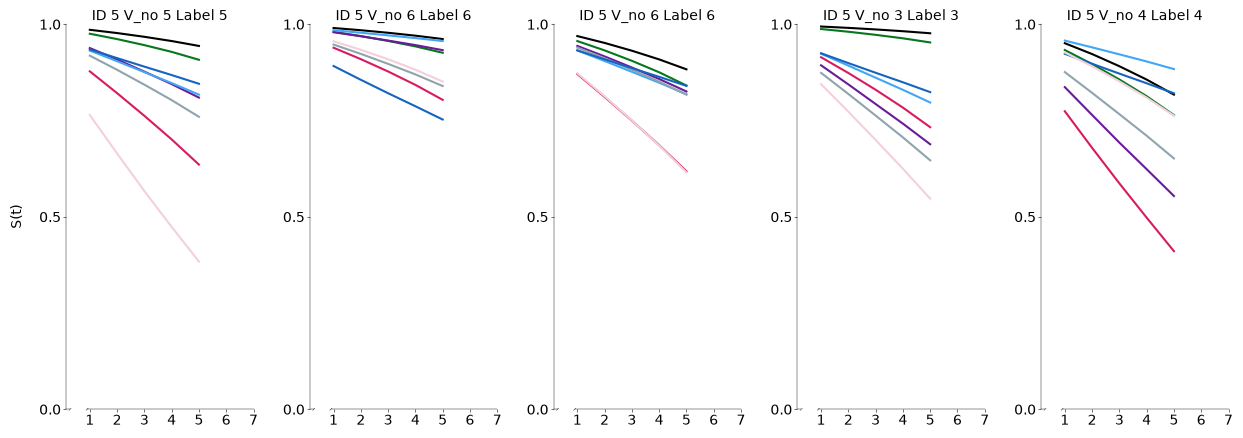

In [41]:
draw_curves(all_images_to_plot, 
            curves_dict0,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/utils/berenslab.mplstyle')